# 03. 모델링과 평가

**과제** Batch 1로 학습하고 Batch 2로 평가한다. **Regression** (타깃: log10 cycle_life, 지표: MAPE).

## 설계 원칙
1. **분할 단위는 프로토콜** — 같은 프로토콜의 쌍둥이 셀이 train/valid로 갈리면 누수가 생긴다 (EDA Q4).
2. **Batch 2는 모델 선택에 사용하지 않는다.** 후보 선택은 Batch 1의 프로토콜 단위 Hold-out(시드를 바꿔 30회 반복)으로만 한다. 최종 모델은 B1 학습 풀로 재학습해 B2에 **1회** 평가한다.
3. 하이퍼파라미터 탐색도 학습 데이터 안의 프로토콜 GroupKFold로만 한다.
4. 학습 라벨은 **36셀**(하한값 가능 0–4번 제외)이 기본이고, 41셀·add_len 보정은 민감도로 보고한다.

| 평가 항목 | 정의 |
|---|---|
| Train (Batch 1 CV) | 프로토콜 단위 GroupKFold(5) out-of-fold MAPE |
| Valid (Batch 1 Hold-out) | 프로토콜 5개를 뺀 Hold-out (시드 42) MAPE |
| Test (Batch 2) | 최종 모델을 B1 36셀 전체로 학습해 B2 39셀에 1회 평가 |
| Gap (Train-Valid) | Valid − Train (+: 과적합 의심) |
| Gap (Valid-Test) | Test − Valid (+: 배치 간 일반화 저하) |
| Gap (Target-Test) | Test − 9.1% (논문 대비, 분할 조건이 달라 **참고 지표**) |

In [1]:
import sys, pathlib, warnings, io, runpy, contextlib
warnings.filterwarnings("ignore")
ROOT = pathlib.Path.cwd().parent if pathlib.Path.cwd().name == "notebooks" else pathlib.Path.cwd()
sys.path.insert(0, str(ROOT))
import numpy as np, pandas as pd
from IPython.display import Image, display
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 30)
from src.config import R, FIG_DIR
from src.data import build_dataset, training_pool, test_set, FEATURE_SETS, FEATURE_SET_DOC

def run_eda(module):
    """EDA 스크립트를 실행해 results/figures 와 results/eda 를 (재)생성한다 (출력은 숨김)."""
    with contextlib.redirect_stdout(io.StringIO()):
        runpy.run_module(module, run_name="__main__")

import json
from src import train, report

## 1. 분할 구조

Batch 1 학습 풀 36셀(20개 프로토콜)에서 프로토콜 5개를 Hold-out으로 뺀다. 가장 짧은 수명 구간을 대표하는 `5.4C(80%)-5.4C`는 항상 Train에 둬 학습 범위를 확보한다.

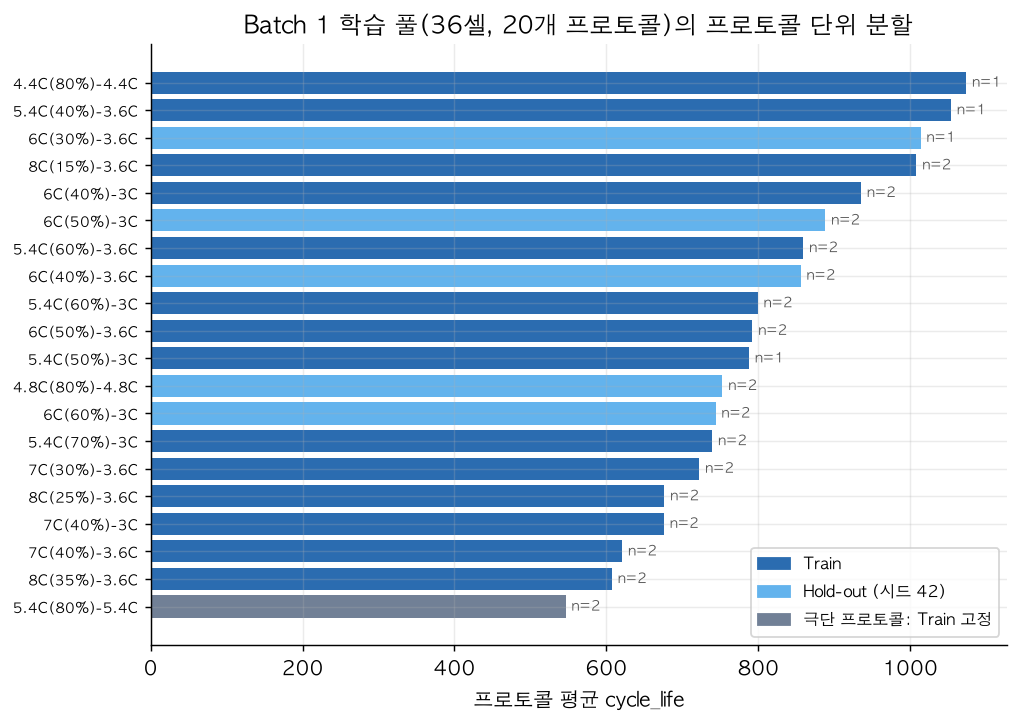

In [2]:
display(Image(str(report.fig_split()), width=700))

## 2. 파이프라인 실행 (후보 25개 탐색 → 선택 → 평가)

- 후보: 피처 세트 A–E × 모델 5종(선형 회귀, Elastic Net, Random Forest, Gradient Boosting, LightGBM)
- 선택 규칙: 반복 Hold-out 평균 MAPE가 최고 성능의 **1 표준오차 이내**인 후보 중 가장 단순한 것(피처 수 → 모델 복잡도)
- **모델 2 (ΔQ 전용)**: Day 1에서 먼저 정한 "ΔQ 핵심 피처(A·B)로 시작" 전략 안에서 같은 규칙으로 선택

In [3]:
res = train.run()      # 약 1분

모델 1: C+LinReg (log_dq_var, qd_slope_91_100, switch, tmax_mean, dq_kurt, qd_2)   모델 2: B+LinReg   | 소요 52s
                        구분  모델 1 (선택: C+LinReg)  모델 2 (ΔQ 전용: B+LinReg)                                 비고
        Train (Batch 1 CV)                  7.0                     7.8  프로토콜 단위 GroupKFold(5) out-of-fold
  Valid (Batch 1 Hold-out)                  7.6                     8.0           프로토콜 단위 Hold-out (시드 42)
            Test (Batch 2)                 40.8                    27.7                   39셀, 최종 모델 1회 평가
         Gap (Train-Valid)                  0.6                     0.2                        (+): 과적합 의심
          Gap (Valid-Test)                 33.2                    19.7                (+): 배치 간 일반화 저하 의심
         Gap (Target-Test)                 31.7                    18.6 Target: 원논문 9.1% (분할 조건이 달라 참고 지표)
           Test: B2 일반 30셀                 46.7                    29.2                기존 구조 셀 (B1과 유사 구조)
  Test: B2 newstructure 9셀           

In [4]:
agg = res["agg"].sort_values("holdout_mean")
display(agg[["feat_set", "model", "n_feat", "holdout_mean", "holdout_std", "valid_official", "selected", "selected_dq_only"]].head(10).round(2))
print(json.dumps({k: res["meta"][k] for k in ["model_1", "model_2_dq_only"]}, ensure_ascii=False, indent=1))

,feat_set,model,n_feat,holdout_mean,holdout_std,valid_official,selected,selected_dq_only
10,C,ElasticNet,6.00,6.78,1.10,7.00,False,False
13,C,LinReg,6.00,6.97,1.26,7.60,True,False
8,B,LinReg,3.00,7.80,1.88,7.99,False,True
20,E,ElasticNet,4.97,8.27,1.62,10.55,False,False
5,B,ElasticNet,3.00,8.30,2.09,10.47,False,False
0,A,ElasticNet,1.00,8.61,1.83,10.44,False,False
3,A,LinReg,1.00,8.65,1.89,10.42,False,False
23,E,LinReg,4.97,8.77,2.33,8.80,False,False
2,A,LightGBM,1.00,8.95,2.15,6.86,False,False
15,D,ElasticNet,15.00,8.96,3.76,7.14,False,False


{
 "model_1": {
  "feature_set": "C",
  "model": "LinReg",
  "features": [
   "log_dq_var",
   "qd_slope_91_100",
   "switch",
   "tmax_mean",
   "dq_kurt",
   "qd_2"
  ],
  "hyperparameters": "",
  "train_cv": 7.02,
  "valid": 7.6,
  "test_b2": 40.84
 },
 "model_2_dq_only": {
  "feature_set": "B",
  "model": "LinReg",
  "features": [
   "log_dq_var",
   "log_dq_min",
   "log_dq_abs_mean"
  ],
  "hyperparameters": "",
  "train_cv": 7.76,
  "valid": 7.99,
  "test_b2": 27.69
 }
}


**참고: Day 1 계획과 다르게 나온 두 곳**
- **세트 B는 규제 모델이 아니라 OLS가 선택됐다.** Day 1에서는 ΔQ 통계 3종의 공선성(0.98–0.99) 때문에 규제 모델을 쓰겠다고 했지만, 반복 Hold-out은 B + 선형 7.80 ± 1.88, B + Elastic Net 8.30 ± 2.09로 OLS가 더 좋았다. 공선성은 **계수 해석**을 불안정하게 하지만 36셀·3피처에서는 **예측 오차**에는 영향이 작았다. 대신 모델 2의 계수는 해석에 쓰지 않는다.
- **세트 C에는 Day 1에서 "기준 미달"이라고 한 전환 SOC·Tmax가 남아 있다.** 세트 C는 Day 1에서 정한 6개를 그대로 후보로 두고 Hold-out으로 검증하는 방침이었고, 아래 원인 분해에서 이 둘의 표준화 계수가 −0.004, −0.002라 영향이 없음을 확인한다.

## 3. 성능 결과 (가이드 Reporting format)

In [5]:
display(res["perf"])

,구분,모델 1 (선택: C+LinReg),모델 2 (ΔQ 전용: B+LinReg),비고
0,Train (Batch 1 CV),7.0,7.8,프로토콜 단위 GroupKFold(5) out-of-fold
1,Valid (Batch 1 Hold-out),7.6,8.0,프로토콜 단위 Hold-out (시드 42)
2,Test (Batch 2),40.8,27.7,"39셀, 최종 모델 1회 평가"
3,Gap (Train-Valid),0.6,0.2,(+): 과적합 의심
4,Gap (Valid-Test),33.2,19.7,(+): 배치 간 일반화 저하 의심
5,Gap (Target-Test),31.7,18.6,Target: 원논문 9.1% (분할 조건이 달라 참고 지표)
6,Test: B2 일반 30셀,46.7,29.2,기존 구조 셀 (B1과 유사 구조)
7,Test: B2 newstructure 9셀,21.2,22.6,newstructure 셀


### Gap 해석

- **Gap (Train-Valid) ≈ 0.2–0.6%p**: 두 모델 모두 B1 안에서는 과적합이 거의 없다(프로토콜 단위로 분리했는데도 Valid가 Train과 같은 수준).
- **Gap (Valid-Test)가 크다 (모델 1: +33%p, 모델 2: +20%p)**: B1 안에서는 7–8%로 논문 수준에 가깝게 맞히지만 B2에서는 크게 무너진다. 이 차이는 **배치 간 일반화 문제**다.
- **Gap (Target-Test) +19–32%p**: 논문 9.1%에 미치지 못한다. 단, 논문의 평가는 B1과 논문 B2(2017-06-30)를 합쳐 홀짝으로 나눈 셀이라 **같은 조건의 목표가 아니다**.

> **핵심 발견: B1 내부 검증은 배치 이동을 감지하지 못한다.**
> B1 Hold-out이 가장 좋다고 한 모델 1(피처 세트 C)은 B2에서 오히려 ΔQ 전용 모델 2보다 나쁘다. 아래 그림이 이를 보여준다.

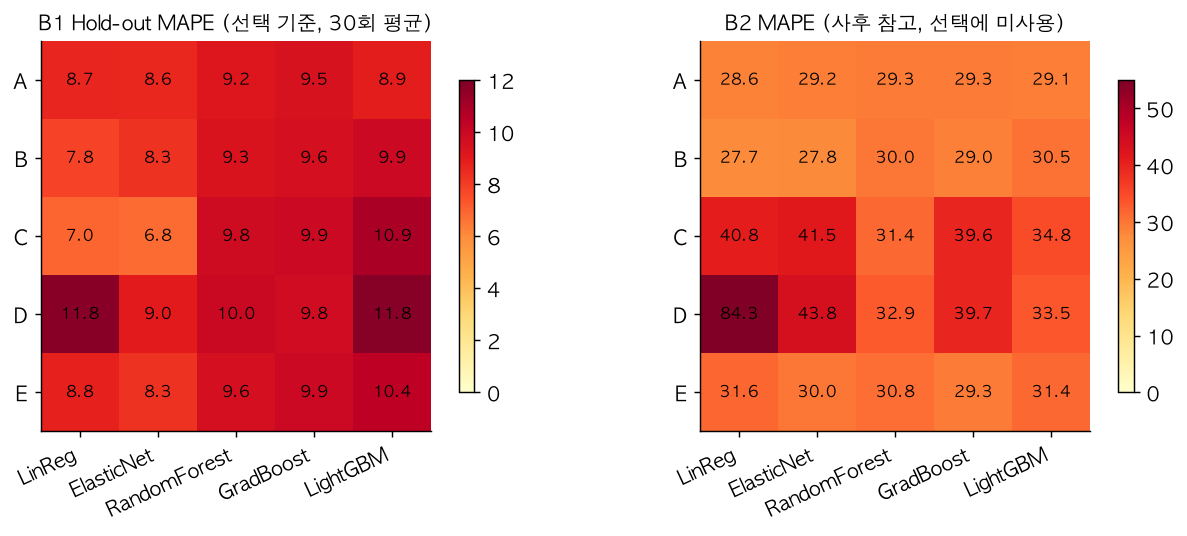

In [6]:
display(Image(str(report.fig_candidates()), width=950))

왼쪽(B1 Hold-out, 선택 기준)에서는 세트 C·B가 좋아 보이지만, 오른쪽(B2, 사후 참고)에서는 세트 A·B·E(ΔQ 중심)가 약 28–31%로 안정적이고 세트 C·D는 선형 모델에서 40% 이상으로 무너진다.
(B2 열은 선택에 쓰지 않았고 선택 후 참고용으로만 계산했다.)

### 원인 분해: 세트 C는 왜 B2에서 무너지는가

처음에는 "세트 C의 전환 SOC·Tmax 같은 **충전 프로토콜 계열 피처** 때문"이라고 추측했다. 그런데 이 설명을 실험으로 확인한 적이 없었다.
피처를 하나씩 더하고 빼며 B1 Valid와 B2를 비교했다 (36셀, 선형 회귀, Hold-out 시드 42).

> ⚠️ B2를 본 뒤에 하는 **사후 분석**이다. 모델 선택에는 쓰지 않고 해석에만 쓴다.

In [7]:
from src.analysis import feature_ablation
feature_ablation.main()

             구성  B1_Valid  B2_전체  B2_일반  B2_new
       A (Var만)      10.4   28.6   31.9    17.5
A + 초기 용량(qd_2)       7.1   45.2   48.1    35.6
     A + 전환 SOC      10.4   28.7   32.3    16.8
       A + Tmax      10.8   28.6   32.0    17.4
           C 전체       7.6   40.8   46.7    21.2
      C − 초기 용량      11.3   28.8   32.6    15.9
     C − 전환 SOC       7.6   41.0   46.8    21.7
       C − Tmax       7.6   41.0   46.9    21.2

C 전체 표준화 계수:
log_dq_var        -0.0826
qd_slope_91_100   -0.0120
switch            -0.0040
tmax_mean         -0.0022
dq_kurt           -0.0144
qd_2               0.0345
  B1 학습 풀 초기 용량 평균: 1.078
  B1 표준편차: 0.0083
  B2 일반 평균: 1.095
  B2 일반 평균의 z(B1 기준): 2.04
  B1 최댓값: 1.095
  B2 일반 중 B1 최댓값 초과: 17/30
  A+초기용량, B2 일반 MAPE (실제 입력): 48.1
  A+초기용량, B2 일반 MAPE (초기용량을 B1 평균으로): 28.2
  B1 초기용량-log수명 상관(단순): 0.16
  B1 초기용량-log수명 편상관(Var[ΔQ] 통제): 0.69

외삽 플래그 구분력:
  모델     범위 플래그  셀수  MAPE
모델 1 전체 39셀  켜짐  38  40.3
모델 1 전체 39셀  꺼짐   1  59.5
모델 1 일반 30셀  켜짐  29  46.3
모델 1

**결과**
- **B2 악화는 초기 용량(`qd_2`) 하나에서 나온다.** A에 초기 용량만 더해도 B1 Valid는 10.4 → 7.1로 좋아지지만 B2는 28.6 → 45.2로 나빠진다. C에서 초기 용량만 빼면 B2가 40.8 → 28.8로 돌아온다.
- **전환 SOC와 Tmax는 B2에 영향이 없다** (더하거나 빼도 거의 같고 표준화 계수도 −0.004, −0.002). 처음의 추측은 **틀렸다.**
- **이유 (확인함):** 초기 용량이 B1 학습 범위 밖으로 이동했다. B2 일반 30셀의 초기 용량 평균 1.095Ah는 B1 학습 풀 평균(1.078)보다 B1 표준편차의 2.0배 높고 30셀 중 17개가 B1 최댓값을 넘는다. A + 초기 용량 모델에서 B2 일반 셀의 초기 용량만 B1 평균으로 바꿔 예측하면 MAPE가 48.1% → 28.2%로 내려간다. B1 안에서 초기 용량-수명 단순 상관은 +0.16으로 약하지만 Var[ΔQ]를 통제한 편상관은 +0.69다 → "초기 용량이 높을수록 수명이 길다"는 **B1 한정의 조건부 관계**였다.
- **B1 지표가 좋아지는 방향으로 피처를 더했는데 B2가 나빠진 것은 초기 용량의 배치 간 분포 이동 때문이다. 그 조건부 관계는 B1에서만 학습됐다.** B1 내부 검증이 이런 이동을 감지하지 못한다는 가장 선명한 증거다.

## 4. 오류 분석 — 모델이 가장 크게 틀린 셀의 공통점

,cell_id,policy,b2_group,cycle_life,pred_m1,signed_pct_err_m1,pred_m2,signed_pct_err_m2,var_out_of_range
21,21,6C(60%)-3C,general,408.0,818.6,100.6,574.799988,40.9,True
6,6,3.6C(9%)-5C,general,393.0,747.5,90.2,569.400024,44.9,False
27,29,5.2C(58%)-4C,general,452.0,827.5,83.1,639.099976,41.4,False
18,18,5.2C(50%)-4.25C,general,449.0,812.2,80.9,649.500000,44.7,False
16,16,4.8C(80%)-4.8C,general,472.0,831.1,76.1,641.400024,35.9,False
19,19,6C(60%)-3C,general,392.0,675.2,72.3,552.200012,40.9,True
0,0,5.2C(58%)-4C,general,477.0,803.3,68.4,627.200012,31.5,False
15,15,3.6C(9%)-5C,general,396.0,652.1,64.7,622.500000,57.2,False


,구분,셀수,M1 MAPE,M2 MAPE,M1 편향,M2 편향
0,B2 전체,39,40.8,27.7,37.7,27.3
1,일반 30셀,30,46.7,29.2,45.9,29.2
2,newstructure 9셀,9,21.2,22.6,10.4,20.9
3,수명 < 450,14,50.1,32.2,48.4,32.2
4,수명 450~550,16,43.8,26.7,43.8,26.7
5,수명 > 550,9,21.2,22.6,10.4,20.9
6,Var[ΔQ] 학습 범위 밖,17,34.0,22.5,27.1,21.6
7,Var[ΔQ] 학습 범위 안,22,46.1,31.7,46.0,31.7


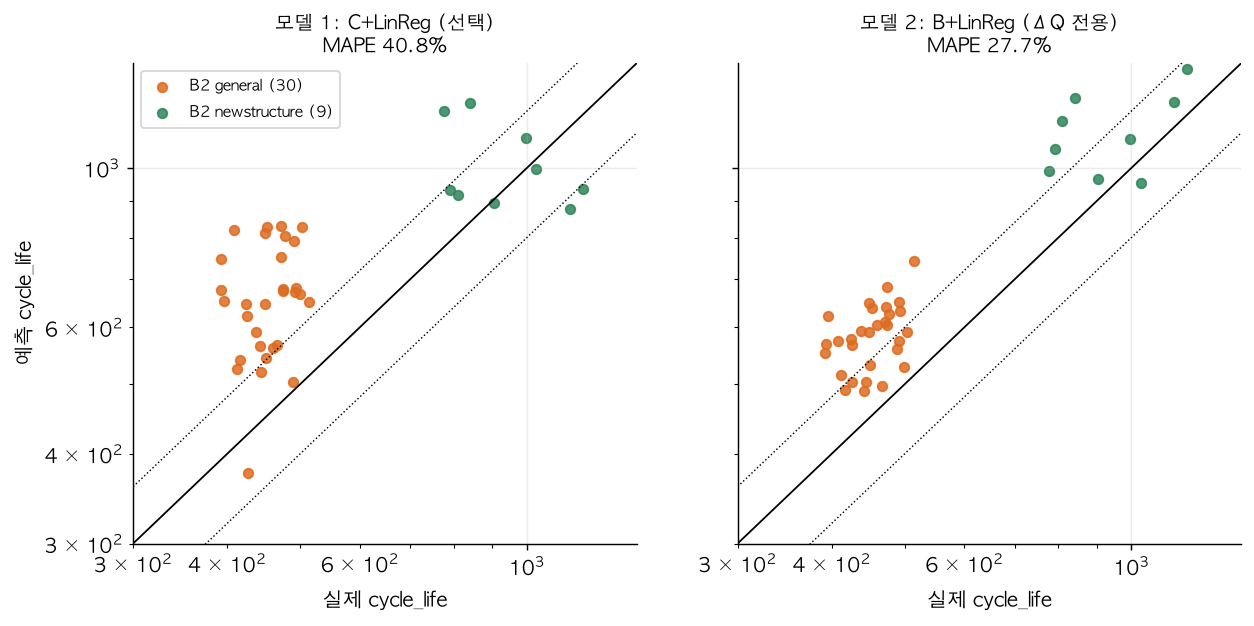

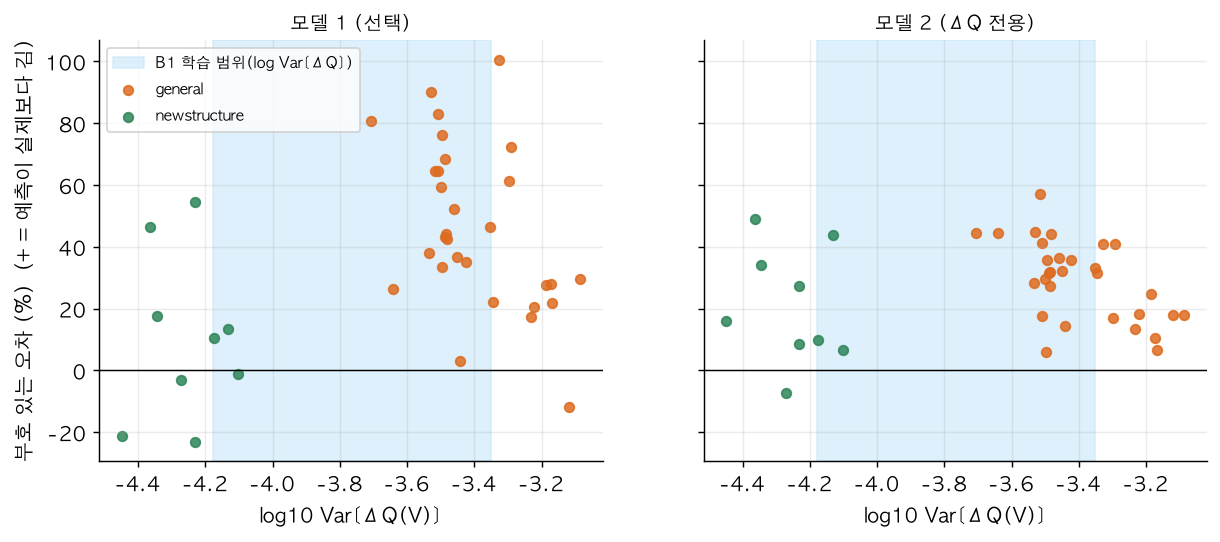

In [8]:
err = res["err"]
worst = err.sort_values("abs_pct_err_m1", ascending=False).head(8)
display(worst[["cell_id", "policy", "b2_group", "cycle_life", "pred_m1", "signed_pct_err_m1", "pred_m2", "signed_pct_err_m2", "var_out_of_range"]].round(1))
display(report.error_summary(err))
display(Image(str(report.fig_pred_vs_true(err)), width=900)); display(Image(str(report.fig_error_vs_var(err, res["pool"])), width=900))

**공통점**
1. 가장 크게 틀린 셀은 **전부 B2 일반 셀**이고, 실제 수명이 가장 짧은 구간(392–477)이다. 예측은 실제보다 **65–100% 길다** (모델 1 기준 상위 8개).
2. 오차의 부호가 거의 한 방향(과대 예측)이다 → 무작위 노이즈가 아니라 **체계적 편향**이다 (MAPE ≈ 부호 있는 오차).
3. **ΔQ 분산은 학습 범위 안인데도 틀린다.** 상위 8개 중 6개는 `log Var[ΔQ]`가 학습 범위 안에 있고, B2 일반 30셀만 보면 범위 안 19개의 오차(52.1%)가 범위 밖 11개(37.5%)보다 크다 (39셀 전체 46.1% vs 34.0%).
   그러나 이것은 피처 **한 개**만 본 것이다. 모델 1의 큰 오차는 **초기 용량이 B1 범위 밖으로 이동한 데서** 나왔다(위 원인 분해). 정리하면 "ΔQ 분산은 범위 안, 초기 용량은 범위 밖"인 **공변량 이동**이다. 타깃도 다르다: 일반 30셀 수명(392–514)은 B1 최솟값(534) 밖이다.
4. newstructure 9셀은 모델 1·2 모두 21–23%로 상대적으로 낫다.

**원인 가설** (검증 불가) 배치별 셀 로트·측정 조건 차이 (초기 용량 평균 B1 학습 풀 1.078 / B2 일반 1.095Ah).
**개선 방향** (모두 검증하지 않은 가설) ① 초기 용량 절대값 피처를 빼거나 배치별로 재보정 (실험이 가리키는 쪽: C − 초기 용량 = B2 28.8%) ② 새 배치마다 소량의 참조 셀 레이블로 재보정 ③ ΔQ를 초기 용량으로 정규화한 피처 시도 (미검증).

                     policy     b2_group  셀수  평균수명  M1_MAPE  M2_MAPE
                 6C(60%)-3C      general   2 400.0     86.4     40.9
                3.6C(9%)-5C      general   2 394.5     77.4     51.0
            5.2C(50%)-4.25C      general   5 454.0     52.6     36.9
               5.2C(58%)-4C      general   4 477.8     48.1     28.9
             4.8C(80%)-4.8C      general   5 483.6     47.8     33.2
             5.6C(26%)-4.5C      general   6 448.5     40.6     22.3
              4.65C(44%)-5C      general   2 482.5     27.7      6.3
4.8C(80%)-4.8C-newstructure newstructure   3 871.7     23.7     26.3
  5.2C(58%)-4C-newstructure newstructure   3 961.7     23.5     21.3
               3.6C(30%)-6C      general   2 421.0     20.7     17.9
              4.65C(69%)-6C      general   2 452.0     19.6     22.5
5.6C(26%)-4.5C-newstructure newstructure   3 991.3     16.4     20.1

모델 1 상위 8개 셀의 프로토콜 분포: {'6C(60%)-3C': 2, '3.6C(9%)-5C': 2, '5.2C(58%)-4C': 2, '5.2C(50%)-4.25C': 1, '4

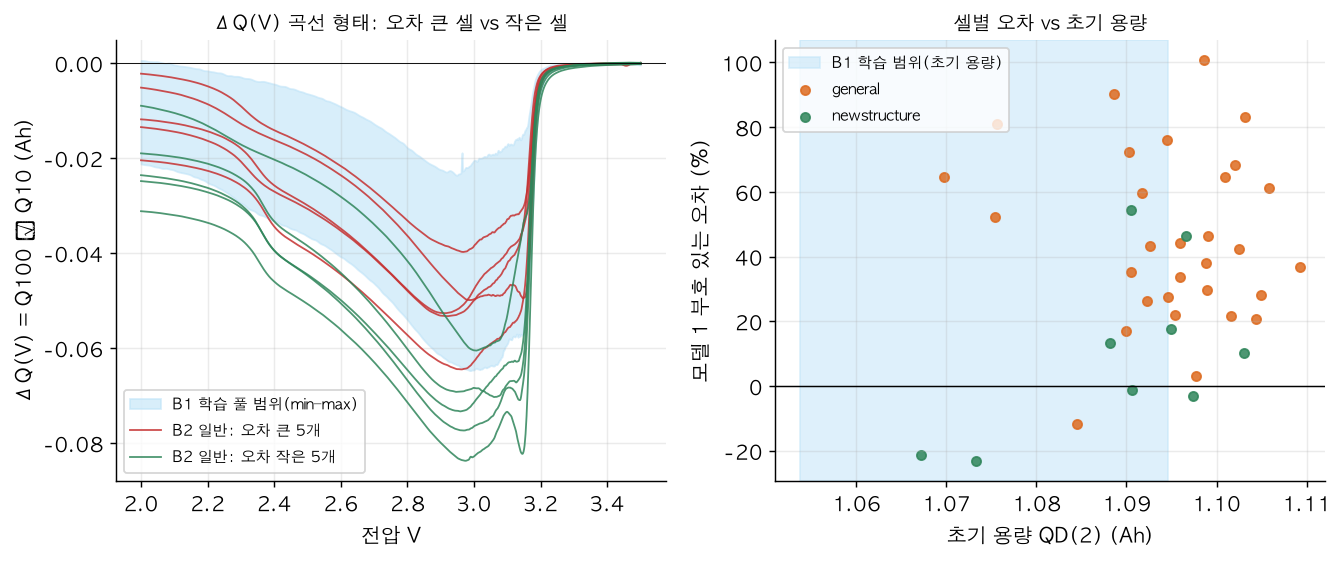

B2 일반 셀 안에서 초기 용량 vs 모델 1 부호 있는 오차: Spearman -0.10 (p=0.61)


In [9]:
from src.analysis import error_by_protocol
prot = error_by_protocol.main()
display(Image(str(report.fig_worst_dq(err)), width=950))
from scipy.stats import spearmanr
g = err[err.b2_group == "general"]
print("B2 일반 셀 안에서 초기 용량 vs 모델 1 부호 있는 오차: Spearman %.2f (p=%.2f)" % spearmanr(g.qd_2, g.signed_pct_err_m1))

**프로토콜과 ΔQ 곡선 형태 (Day 1에서 약속한 확인 항목)**
- **프로토콜은 오차를 설명하지 않는다.** 일반 셀의 프로토콜별 평균 수명은 394.5–483.6으로 거의 같은데 모델 1 MAPE는 19.6%(4.65C(69%)-6C)에서 86.4%(6C(60%)-3C)까지 갈린다 (프로토콜당 2–6셀이라 추정이 거칠다).
- **ΔQ 곡선 형태**: 오차가 큰 일반 셀은 ΔQ(V)가 상대적으로 얕아 B1 학습 풀 범위 안쪽에 있다 — B1에서는 더 긴 수명에 해당하는 형태다. 오차가 작은 셀은 더 깊게 파여 일부는 B1 범위 밖에 닿는다.
- **초기 용량은 셀 간 변동이 아니라 배치 수준의 이동이다**: B2 일반 셀 안에서 초기 용량과 모델 1 오차의 상관은 거의 없다. 또한 초기 용량 피처가 없는 모델 2도 일반 셀을 +29% 과대 예측하므로, 초기 용량은 모델 1의 **추가 악화**(약 41% vs 28%)를 설명하고 ΔQ 전용 모델에 남는 약 28%는 초기 용량으로 설명되지 않는 별도의 배치 이동이다.

## 5. 민감도와 보조 점검

In [10]:
display(res["sens"])
print("B1 내부 '수명 외삽' 검증 (가장 짧은 프로토콜 k개를 빼고 학습, MAPE %):")
p = pathlib.Path(R("shift_check_b1.csv"))
display(pd.read_csv(p, index_col=0) if p.exists() else "run: python -m src.analysis.shift_check")

,model,train_labels,B2,B2_general,B2_new,bias_general,bias_new
0,모델 1,36셀 (기본),40.8,46.7,21.2,45.9,10.4
1,모델 2,36셀 (기본),27.7,29.2,22.6,29.2,20.9
2,모델 1,원 라벨 41셀,49.5,57.1,24.4,57.1,17.2
3,모델 2,원 라벨 41셀,33.8,39.8,13.5,39.8,7.9
4,모델 1,add_len 보정 41셀,44.5,45.7,40.4,45.7,39.8
5,모델 2,add_len 보정 41셀,25.7,25.7,25.4,25.7,23.5


B1 내부 '수명 외삽' 검증 (가장 짧은 프로토콜 k개를 빼고 학습, MAPE %):


,ElasticNet,GradBoost,LightGBM,LinReg,RandomForest
feat_set,,,,,
A,8.7,24.5,19.4,7.2,21.2
B,8.5,24.7,19.2,8.7,19.4
C,5.0,20.8,19.7,5.2,19.5
D,7.3,21.7,21.9,8.8,21.5
E,7.7,22.5,21.2,7.6,19.5


- **라벨 처리 민감도**: 하한값 라벨(0–4번)을 포함하거나 add_len으로 보정하면 B2 성능이 달라지지만, 집단마다 방향이 달라 어느 쪽이 항상 낫지 않다.
  36셀(관측 라벨만)을 기본으로 한 이유는 외부 상수가 필요 없고 검열된 라벨을 정확값처럼 쓰지 않기 때문이다. 단점은 학습 최대 수명이 1,074로 낮아진다는 점이다.
- **B1 내부 외삽 검증**: 수명이 가장 짧은 프로토콜을 빼고 학습해도 세트 C가 오히려 가장 좋다. 즉 B2의 성능 저하는 "수명 범위 외삽"이 아니라 **프로토콜 → 수명 관계가 배치마다 다른 이동**이다. B1만으로는 이를 사전에 감지할 수 없다.

## 6. ESS 도메인 해석

**활용 가능한 의사결정**
- *교체 시점 계획*: 초기 100 사이클의 ΔQ(V) 신호만으로 수명 규모를 가늠해 교체 CAPEX(ESS의 30–40%)를 사전 계획한다. 같은 배치(같은 셀 로트) 안에서는 B1 Hold-out 수준(약 7–8%)의 정밀도가 기대된다.
- *제조 직후 불량 셀 선별*: `log Var[ΔQ]`가 큰 셀(수명이 짧을 가능성)을 초기 선별해 팩 구성을 최적화한다.

**한계와 실 배포를 위한 추가 요건**
- **배치 간 일반화가 약하다**: 새 셀 로트가 들어오면 같은 ΔQ에서도 수명이 달라질 수 있다 (B2 일반 셀: 과대 예측 +29–46%). 실제 운영에서는 **새 로트마다 소량의 보정 데이터(참조 셀 수명)로 재보정**해야 한다.
- 학습 범위 밖 입력에는 **외삽 경고 플래그**를 단다(`results/error_analysis_b2.csv`의 `extrapolation_m1/m2`, `var_out_of_range`). 플래그의 구분력은 모델마다 다르다(`results/extrapolation_flag_check.csv`): 모델 1은 39셀 중 38개에서 켜져 구분 능력이 없고, 모델 2는 켜진 셀의 오차(22.5%)가 꺼진 셀(31.7%)보다 오히려 작아 큰 오차를 가려내지 못한다. 범위 이탈 플래그만으로는 충분하지 않다.
- 표본이 작다(36셀, 20개 프로토콜). 초기 용량 같은 **절대값 피처**는 셀 로트가 바뀌면 오히려 해가 될 수 있다(B1 Valid는 좋아지는데 B2는 나빠졌다). 새 배치에서는 쓰기 전에 다시 검증해야 한다.
- 이 결과는 과제 지정 Batch 2(논문 배치 아님) 기준이며 논문 9.1%와 같은 조건의 비교가 아니다.